# 08. 품목 확대 — 표본을 늘리면 달라지는가

06·07번에서 막다른 길이 두 번 나왔다.

- **06번**: 22개 피처를 새로 조합해 얻은 게 MAPE 1.1%. 모델 용량도 병목이 아니었다.
- **07번**: 외부 데이터 1순위였던 관세청 수입량이 값을 하지 않았다.

남은 가설은 **표본 부족**이었다. 6품목 × 1,371일로는 무엇을 넣어도 개선이
잡음에 묻히는 것 아닌가. 그래서 품목을 늘려 확인한다.

이 노트북에서 하는 것:

1. 후보 선정과 수집 — 무엇을 넣고 무엇을 뺐는지
2. **노이즈 플로어를 제대로 잰다** — 07번의 해석이 틀렸다
3. 확대 효과 — 기존 품목과 신규 품목을 나눠서
4. 어떤 품목이 모델에 맞는가

In [1]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import font_manager
from sklearn.ensemble import HistGradientBoostingRegressor

_available = {f.name for f in font_manager.fontManager.ttflist}
for _f in ("AppleGothic", "Apple SD Gothic Neo", "NanumGothic", "Malgun Gothic"):
    if _f in _available:
        plt.rcParams["font.family"] = _f
        break
plt.rcParams["axes.unicode_minus"] = False
sns.set_style("whitegrid", {"font.family": plt.rcParams["font.family"]})

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
df = pd.read_parquet(ROOT / "notebooks" / ".cache" / "mart.parquet")
df["price_date"] = pd.to_datetime(df["price_date"])
df = df.sort_values(["item", "price_date"]).reset_index(drop=True)

OLD6 = ["감자", "미나리", "배추", "생강", "양파", "파"]
NEW = [i for i in sorted(df.item.unique()) if i not in OLD6]
print(f"{len(df):,}행 | 품목 {df.item.nunique()}개 (기존 {len(OLD6)} + 신규 {len(NEW)})")
print("신규:", ", ".join(NEW))
print(f"\n기상 NULL {df.temp_avg.isna().mean()*100:.1f}% · "
      f"출하량 NULL {df.shipment_qty.isna().mean()*100:.1f}% "
      "— 신규 품목은 매핑이 없어 비어 있다")

22,589행 | 품목 17개 (기존 6 + 신규 11)
신규: 고구마, 깐마늘(국산), 깻잎, 무, 상추, 시금치, 양배추, 얼갈이배추, 열무, 풋고추, 피마늘

기상 NULL 63.6% · 출하량 NULL 63.9% — 신규 품목은 매핑이 없어 비어 있다


## 1. 후보 선정과 수집

### 매핑 비용이 생각보다 작았다

06번에서 "품목당 datago 코드·기상 지점 매핑이 실제 비용"이라고 봤는데,
**datago 응답이 코드와 한글 이름을 같이 준다**(`gds_lclsf_nm`, `gds_mclsf_nm`).
대분류·중분류를 훑으면 37개 조합의 이름표가 그대로 나와서, 사람이 코드를
찾아 헤맬 필요가 없다.

| 대분류 | 미수집 후보 |
|---|---|
| 엽경채류(10) | 얼갈이배추·양배추·상추·열무·시금치·부추·깻잎·쑥갓·갓·근대·아욱 |
| 조미채소(12) | 쪽파·실파·풋고추·꽈리고추·건고추·홍고추·마늘·양하 |
| 서류(05) | 고구마 |
| 과실류(06) | 사과·배·포도·복숭아·감귤 등 |

### 실제 제약은 datago 일일한도

기존 6품목 × 1,672일 = **10,032 요청**으로 하루 한도(1만)가 이미 찬다. 품목을
늘리면 백필을 며칠에 나눠야 한다. 그래서 **KAMIS 가격만 먼저** 받았다
(품목당 연 단위 요청이라 13품목이 82요청, 몇 분이면 끝난다).

### 수집 결과와 선별

13품목을 받아 품질로 걸렀다. **전부 `unit_base='kg'`** 이라 마트에 그대로 들어간다
(`v_price_daily` 가 kg 조건을 걸기 때문에 이게 중요하다).

| 판정 | 품목 | 근거 |
|---|---|---|
| 채택 (10) | 시금치·상추·얼갈이배추·깻잎·열무·양배추·풋고추·고구마·무·깐마늘(국산) | 각 1,372일, 기존과 같은 커버리지 |
| 제외 | **부추 · 쪽파** | KAMIS 일별 도매가 **0행**. 월별엔 있어도 일별은 없다 |
| 제외 | **피마늘** | 648일뿐 — 다른 품목의 절반도 안 된다. 마늘은 깐마늘로 받는다 |

### `--replace-range` 를 쓰지 않은 이유

구간 삭제는 **날짜 기준이라 품목을 가리지 않는다.** 신규 품목을 넣겠다고
`--start 2021-01-01 --end 2026-08-07 --replace-range` 를 돌렸다면 **기존 6품목
69,861행이 통째로 날아간다.** 신규 품목은 기존과 겹치지 않으므로 `append` 가 맞다.

In [2]:
cov = df.groupby("item").agg(
    행수=("price_date", "size"), 일수=("price_date", "nunique"),
    시작=("price_date", "min"), 종료=("price_date", "max"),
    기상NULL=("temp_avg", lambda s: round(s.isna().mean() * 100, 1)),
)
cov["구분"] = np.where(cov.index.isin(OLD6), "기존", "신규")
display(cov.sort_values(["구분", "일수"], ascending=[True, False]))

,행수,일수,시작,종료,기상NULL,구분
item,,,,,,
감자,1371,1371,2021-01-04,2026-08-06,0.0,기존
미나리,1371,1371,2021-01-04,2026-08-06,0.0,기존
배추,1371,1371,2021-01-04,2026-08-06,0.0,기존
생강,1371,1371,2021-01-04,2026-08-06,0.0,기존
파,1371,1371,2021-01-04,2026-08-06,0.0,기존
양파,1365,1365,2021-01-04,2026-08-06,0.0,기존
깐마늘(국산),1373,1373,2021-01-04,2026-08-07,100.0,신규
고구마,1372,1372,2021-01-04,2026-08-07,100.0,신규
깻잎,1372,1372,2021-01-04,2026-08-07,100.0,신규


## 2. 노이즈 플로어를 제대로 잰다 — 07번 해석 정정

07번에서 **"미나리는 수입 피처가 100% 결측인데도 -0.194 움직였으니 ±0.2 는
노이즈"** 라고 썼다. **이 해석은 틀렸다.**

노이즈를 재려면 **정보가 전혀 없는 입력**을 넣어보면 된다. 난수 피처 4개를
(07번 수입 피처와 같은 개수) 추가하고 seed 를 바꿔가며 성능이 얼마나 흔들리는지
본다. 이게 "입력이 무의미하게 바뀔 때의 변동폭"이다.

참고로 `random_state` 만 바꾸는 것으로는 못 잰다. `early_stopping=False` 에
`max_features` 기본값이면 `HistGradientBoosting` 은 **완전 결정론적**이라
표준편차가 정확히 0 이 나온다(실측).

피처는 **가격·달력만** 쓴다. 신규 품목은 기상·출하량이 비어 있어 그대로 넣으면
기존 품목과 공정한 비교가 안 되기 때문이다.

In [3]:
H = 7
EMBARGO = pd.Timedelta(days=int(H * 1.5))
FOLDS = [("2023-01-01", "2023-06-30"), ("2023-07-01", "2023-12-31"),
         ("2024-01-01", "2024-06-30"), ("2024-07-01", "2024-12-31"),
         ("2025-01-01", "2025-06-30"), ("2025-07-01", "2025-12-31"),
         ("2026-01-01", "2026-12-31")]
TUNED = dict(learning_rate=0.014, max_iter=502, min_samples_leaf=21,
             max_leaf_nodes=15, l2_regularization=1.0)
CAL = ["month", "dayofweek", "days_to_major_holiday", "days_since_major_holiday",
       "days_since_solar_term"]


def build(src):
    d = src.copy()
    d["_logp"] = np.log(d.price_kg_avg)
    its = sorted(d.item.unique())

    def g(c):
        return d.groupby("item")[c]

    d["y"] = g("_logp").shift(-H) - d._logp
    for lag in (1, 2, 3, 5, 10, 20):
        d[f"ret{lag}"] = d._logp - g("_logp").shift(lag)
    for w in (5, 20, 60):
        mp = max(2, w // 3)
        d[f"dev{w}"] = d._logp - g("_logp").transform(
            lambda s: s.rolling(w, min_periods=mp).mean())
        d[f"vol{w}"] = g("_logp").transform(
            lambda s: s.diff().rolling(w, min_periods=mp).std())
    doy = d.price_date.dt.dayofyear
    d["doy_sin"] = np.sin(2 * np.pi * doy / 365.25)
    d["doy_cos"] = np.cos(2 * np.pi * doy / 365.25)
    d["seas_dev"] = d._logp - (d.groupby(["item", "month"])["_logp"]
                               .transform(lambda s: s.shift(1).expanding(min_periods=20).mean()))
    d["item_code"] = pd.Categorical(d.item, categories=its).codes
    return d.dropna(subset=["y"]).reset_index(drop=True)


FEATS = ([f"ret{l}" for l in (1, 2, 3, 5, 10, 20)] + [f"dev{w}" for w in (5, 20, 60)]
         + [f"vol{w}" for w in (5, 20, 60)] + CAL
         + ["doy_sin", "doy_cos", "seas_dev", "item_code"])


def predict(feat, feats):
    cat = [feats.index(c) for c in ("item_code", "month", "dayofweek")]
    out = []
    for s, e in FOLDS:
        s, e = pd.Timestamp(s), pd.Timestamp(e)
        tr = feat[feat.price_date < s - EMBARGO]
        te = feat[(feat.price_date >= s) & (feat.price_date <= e)]
        m = HistGradientBoostingRegressor(
            loss="absolute_error", categorical_features=cat, early_stopping=False,
            random_state=42, **TUNED).fit(tr[feats], tr.y)
        t = te[["item", "y"]].copy()
        t["pred"] = m.predict(te[feats])
        out.append(t)
    r = pd.concat(out)
    r["ape"] = np.abs(np.exp(r.pred) - np.exp(r.y)) / np.exp(r.y) * 100
    r["naive"] = np.abs(1 - np.exp(r.y)) / np.exp(r.y) * 100
    return r


def mape(r, only=None):
    if only is not None:
        r = r[r.item.isin(only)]
    return r.groupby("item").ape.mean().mean()


t0 = time.time()
feat6 = build(df[df.item.isin(OLD6)])
r6 = predict(feat6, FEATS)
base6 = mape(r6)
print(f"6품목 기준선 {base6:.3f}\n\n난수 피처 4개를 넣었을 때:")
noise = []
for sd in (1, 2, 3, 4, 5):
    rng = np.random.default_rng(sd)
    f = feat6.copy()
    cols = [f"rnd{i}" for i in range(4)]
    for c in cols:
        f[c] = rng.normal(size=len(f))
    v = mape(predict(f, FEATS + cols))
    noise.append(v - base6)
    print(f"  seed{sd}: {v:.3f}  ({v - base6:+.3f})")
NOISE_RANGE = max(noise) - min(noise)
print(f"\n노이즈 플로어: 표준편차 {np.std(noise):.3f}, 최대폭 {NOISE_RANGE:.3f}")
print(f"({time.time()-t0:.0f}초)")

6품목 기준선 8.201

난수 피처 4개를 넣었을 때:


  seed1: 8.204  (+0.002)


  seed2: 8.219  (+0.018)


  seed3: 8.185  (-0.016)


  seed4: 8.188  (-0.013)


  seed5: 8.205  (+0.003)

노이즈 플로어: 표준편차 0.012, 최대폭 0.034
(78초)


## 3. 확대 효과 — 나눠서 봐야 한다

**평가 대상을 어디로 잡느냐에 따라 결론이 뒤집힌다.**

- 기존 6품목만 보면: 확대가 **손해**로 보인다
- 신규 품목까지 보면: 확대가 **이득**이다

둘 다 재서 나란히 놓는다.

In [4]:
feat17 = build(df)
r17 = predict(feat17, FEATS)

summary = pd.DataFrame([
    {"학습": "6품목", "평가": "기존 6품목", "MAPE": mape(r6)},
    {"학습": "17품목", "평가": "기존 6품목", "MAPE": mape(r17, OLD6)},
    {"학습": "17품목", "평가": "신규 11품목", "MAPE": mape(r17, NEW)},
    {"학습": "17품목", "평가": "전체 17품목", "MAPE": mape(r17)},
])
display(summary.round(3))

d6 = mape(r17, OLD6) - mape(r6)
print(f"기존 6품목에 대한 영향: {d6:+.3f}")
print(f"  노이즈 최대폭 {NOISE_RANGE:.3f} 의 {abs(d6)/max(1e-9, NOISE_RANGE):.1f}배 → "
      f"{'실재하는 변화' if abs(d6) > NOISE_RANGE else '잡음 범위'}")

nv6 = r17[r17.item.isin(OLD6)].groupby("item").naive.mean().mean()
nvn = r17[r17.item.isin(NEW)].groupby("item").naive.mean().mean()
print(f"\nnaive 대비 개선: 기존 6품목 {mape(r17, OLD6)-nv6:+.3f} | "
      f"신규 11품목 {mape(r17, NEW)-nvn:+.3f}")

,학습,평가,MAPE
0,6품목,기존 6품목,8.201
1,17품목,기존 6품목,8.310
2,17품목,신규 11품목,11.051
3,17품목,전체 17품목,10.084


기존 6품목에 대한 영향: +0.108
  노이즈 최대폭 0.034 의 3.2배 → 실재하는 변화

naive 대비 개선: 기존 6품목 -0.482 | 신규 11품목 -0.953


## 4. 어떤 품목이 모델에 맞는가

품목별로 **naive 대비 개선**을 본다. 품목마다 오차 수준이 달라 절대 MAPE 로는
비교가 안 되고, 04번에서 확인했듯 비율로 보면 오차가 낮은 품목이 과대 반영된다.
그래서 **차이(모델 MAPE − naive MAPE)** 로 본다.

,ape,naive,naive대비,구분
item,,,,
시금치,14.297,17.620,-3.323,신규
상추,19.355,22.018,-2.663,신규
얼갈이배추,11.355,13.205,-1.850,신규
미나리,10.628,12.241,-1.613,기존
풋고추,16.666,18.126,-1.459,신규
깻잎,12.123,13.484,-1.361,신규
배추,12.627,13.717,-1.090,기존
열무,11.141,11.931,-0.790,신규
양파,5.301,5.666,-0.364,기존


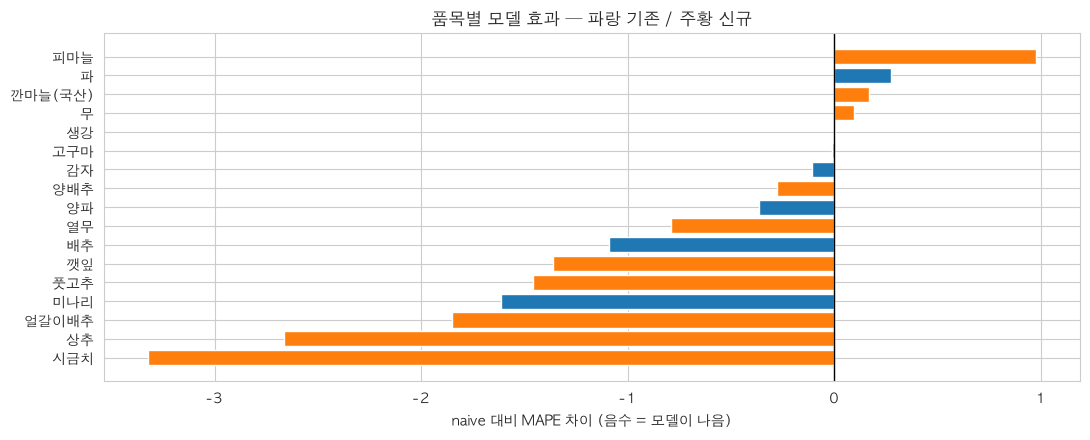

In [5]:
per = r17.groupby("item")[["ape", "naive"]].mean()
per["naive대비"] = per.ape - per.naive
per["구분"] = np.where(per.index.isin(OLD6), "기존", "신규")
per = per.sort_values("naive대비")
display(per.round(3))

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.barh(per.index, per.naive대비,
        color=["tab:blue" if c == "기존" else "tab:orange" for c in per.구분])
ax.axvline(0, color="black", lw=1)
ax.set_xlabel("naive 대비 MAPE 차이 (음수 = 모델이 나음)")
ax.set_title("품목별 모델 효과 — 파랑 기존 / 주황 신규")
plt.tight_layout()
plt.show()

## 5. 정리

### 노이즈 플로어는 ±0.03 이다 — 07번 해석은 틀렸다

난수 피처 4개를 넣고 seed 를 바꿔가며 재니 **표준편차 0.012, 최대폭 0.034** 였다.
07번에서 "±0.2 가 노이즈"라고 본 것은 **6배 과대평가**였다.

그러면 07번의 판정 근거도 다시 읽어야 한다. 수입 피처의 전체 +0.073 은 노이즈의
2배가 넘으므로 **잡음이 아니라 실재하는 악화**였다. 미나리의 -0.194 도 잡음이
아니라 "다른 품목의 입력이 바뀌면 그 품목 예측도 실제로 달라진다"는 현상이다.
방향을 통제할 수 없을 뿐이다. **07번의 결론(수입 피처 채택 안 함)은 그대로지만
근거는 "무의미해서"가 아니라 "실제로 나빠져서"로 바뀐다.**

교훈: 노이즈 플로어는 **결측 없는 난수 피처**로 재야 한다. 결측이 많은 실제
피처의 변동폭을 노이즈로 삼으면 기준이 과하게 느슨해진다.

### 확대 효과 — 평가 대상에 따라 결론이 뒤집힌다

| 학습 | 평가 | MAPE |
|---|---|---|
| 6품목 | 기존 6품목 | 8.201 |
| 17품목 | 기존 6품목 | **8.310** (+0.108) |
| 17품목 | 신규 11품목 | 11.051 |
| 17품목 | 전체 17품목 | 10.084 |

**기존 6품목만 보면 +0.108 악화**다. 노이즈(0.034)의 3.2배라 실재하는 변화다.
품목이 늘면서 트리가 17개 품목에 분산된 대가로 보인다.

그런데 **naive 대비 개선**으로 보면 그림이 뒤집힌다.

- 기존 6품목: **-0.482**
- 신규 11품목: **-0.953** — 기존의 두 배다

즉 **신규 품목이 기존보다 모델이 잘 듣는다.** 기존 품목에서 잃은 0.108 보다
신규 품목에서 얻는 게 훨씬 크다. **확대는 이득이다.**

### 어떤 품목이 모델에 맞는가 — 엽채류다

naive 대비 상위 8개 중 **6개가 신규 품목**이고, 그 성격이 뚜렷하다.

| 상위 (모델이 잘 듣는다) | 하위 (모델이 무의미하거나 해롭다) |
|---|---|
| 시금치 -3.32 · 상추 -2.66 · 얼갈이배추 -1.85 | 무 +0.10 · 깐마늘 +0.17 · 파 +0.28 · 피마늘 +0.98 |
| 미나리 -1.61 · 풋고추 -1.46 · 깻잎 -1.36 | 생강 +0.00 · 고구마 -0.01 · 감자 -0.11 |

**엽채류(시금치·상추·얼갈이배추·깻잎·열무·미나리)가 전부 상위**에 있고,
**저장·가공 품목(무·마늘·고구마·감자·생강)이 전부 하위**다.

06번에서 미나리 하나를 두고 "시설 재배로 회전이 빠르고 수요에 직접 반응해서
잡힌다"고 해석했는데, **품목군 단위로 재현됐다.** 반대로 "저장 작물은 재고와
수입에 좌우돼 안 된다"는 해석도 신규 품목에서 그대로 나타난다.

**파가 +0.278 로 악화된 것**은 주의해야 한다. 03번에서 파는 5/7 승률로 모델을
쓰는 쪽이었는데, 품목이 늘자 뒤집혔다. 확대가 모든 기존 품목에 이로운 게 아니다.

### 한계

- 신규 품목은 **기상·출하량이 전부 NULL** 이다. 가격·달력만으로 이 성능이므로,
  매핑을 붙이면 더 오를 여지가 있다.
- 피마늘(648일)은 데이터가 절반이라 성능 해석에서 빼는 게 맞다. `config/items.py`
  에는 이미 제외했지만 이번 마트에는 남아 있다.
- 기존 6품목의 +0.108 은 실재한다. 품목별 모델이나 품목군별 모델이면 피할 수
  있는 손해인지는 아직 확인하지 않았다.

### 다음

1. **신규 품목 datago 출하량 수집** — 일일한도 때문에 하루 6품목씩 나눠야 한다.
   기상은 `ITEM_STATIONS` 에 주산지를 사람이 정해줘야 한다.
2. **품목군별 모델 분리 검토** — 엽채류와 저장작물이 이렇게 다르면 한 모델로
   묶는 게 최선이 아닐 수 있다. 파가 확대로 악화된 것도 같은 맥락이다.
3. **엽채류 품목을 더 넣는 것**도 유효해 보인다 — 아직 안 받은 후보로 쑥갓·갓·
   근대·아욱·부추(일별 없음)·양상추·청경채 등이 있다.
